In [1]:
import pandas as pd
import numpy as np
from zipfile import ZipFile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from hdbscan import HDBSCAN

pd.set_option("display.max_columns", 100)

In [4]:
zip_path = "data/queensland.zip"
csv_filename = "_1_crash_locations.csv"

with ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open(csv_filename) as csv_file:
        df = pd.read_csv(csv_file)

print(df.shape)
df.head()

C:\Users\Владимир Савинский\AppData\Local\Temp\ipykernel_10612\2610497744.py:6: DtypeWarning: Columns (0: Crash_DCA_Code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


(408271, 52)


,Crash_Ref_Number,Crash_Severity,Crash_Year,Crash_Month,Crash_Day_Of_Week,Crash_Hour,Crash_Nature,Crash_Type,Crash_Longitude,Crash_Latitude,Crash_Street,Crash_Street_Intersecting,State_Road_Name,Loc_Suburb,Loc_Local_Government_Area,Loc_Post_Code,Loc_Police_Division,Loc_Police_District,Loc_Police_Region,Loc_Queensland_Transport_Region,Loc_Main_Roads_Region,Loc_ABS_Statistical_Area_2,Loc_ABS_Statistical_Area_3,Loc_ABS_Statistical_Area_4,Loc_ABS_Remoteness,Loc_State_Electorate,Loc_Federal_Electorate,Crash_Controlling_Authority,Crash_Roadway_Feature,Crash_Traffic_Control,Crash_Speed_Limit,Crash_Road_Surface_Condition,Crash_Atmospheric_Condition,Crash_Lighting_Condition,Crash_Road_Horiz_Align,Crash_Road_Vert_Align,Crash_DCA_Code,Crash_DCA_Description,Crash_DCA_Group_Description,DCA_Key_Approach_Dir,Count_Casualty_Fatality,Count_Casualty_Hospitalised,Count_Casualty_MedicallyTreated,Count_Casualty_MinorInjury,Count_Casualty_Total,Count_Unit_Car,Count_Unit_Motorcycle_Moped,Count_Unit_Truck,Count_Unit_Bus,Count_Unit_Bicycle,Count_Unit_Pedestrian,Count_Unit_Other
0,1,Medical treatment,2006,November,Saturday,17,Hit parked vehicle,Single Vehicle,153.549734,-28.165245,Boundary St,NaN,NaN,Coolangatta,Gold Coast City,4225,Coolangatta,Gold Coast,South Eastern,SEQ South,South Coast,Coolangatta,Coolangatta,Gold Coast,Major Cities,Currumbin,Mcpherson,Locally-controlled,No Roadway Feature,No traffic control,0 - 50 km/h,Sealed - Dry,Clear,Daylight,Straight,Grade,703,Off Path-Straight: Left Off Cway Hit Obj,16: Off Carriageway on Straight Hit Object,E,0,0,1,0,1,2,1,0,0,0,0,0
1,2,Property damage only,2007,August,Wednesday,9,Rear-end,Multi-Vehicle,153.055073,-27.524438,South East Arterial Rd,NaN,South-East Arterial Road (Pacific Motorway),Holland Park West,Brisbane City,4121,Holland Park,South Brisbane,Brisbane,SEQ South,Metropolitan,Tarragindi,Nathan,Brisbane - South,Major Cities,Miller,Moreton,State-controlled,No Roadway Feature,No traffic control,100 - 110 km/h,Sealed - Dry,Clear,Daylight,Straight,Level,301,Vehs Same Direction: Rear End,04: Rear-end,N,0,0,0,0,0,2,0,1,0,0,0,0
2,3,Hospitalisation,2008,May,Saturday,17,Hit object,Single Vehicle,153.407116,-28.048178,Markeri St,Southport - Burleigh Rd,Southport - Burleigh Road,Mermaid Waters,Gold Coast City,4218,Broadbeach,Gold Coast,South Eastern,SEQ South,South Coast,Mermaid Waters,Broadbeach - Burleigh,Gold Coast,Major Cities,Mermaid Beach,Mcpherson,State-controlled,Intersection - Cross,Operating traffic lights,60 km/h,Sealed - Wet,Raining,Darkness - Lighted,Straight,Level,708,Off Path-Straight: Mounts Traffic Island,16: Off Carriageway on Straight Hit Object,S,0,1,0,0,1,0,1,0,0,0,0,0
3,4,Hospitalisation,2007,August,Sunday,2,Hit pedestrian,Hit pedestrian,146.712389,-19.262326,Ingham Rd,NaN,NaN,Bohle,Townsville City,4818,Townsville,Townsville,Northern,Northern,North Queensland,Mount Louisa,Townsville,Townsville,Outer Regional,Townsville,Herbert,Locally-controlled,No Roadway Feature,No traffic control,80 - 90 km/h,Sealed - Dry,Clear,Darkness - Not lighted,Straight,Level,3,Pedn: Far Side Vehicle Hit From Left,12: Pedestrian,E,0,1,0,0,1,1,0,0,0,0,1,0
4,5,Hospitalisation,2007,June,Wednesday,1,Hit object,Single Vehicle,152.788149,-26.972672,D'Aguilar Hwy,NaN,D'Aguilar Highway (Caboolture - Kilcoy),Woodford,Moreton Bay Region,4514,Woodford,Moreton,North Coast,SEQ North,North Coast,Woodford - Daguilar,Caboolture Hinterland,Moreton Bay - North,Inner Regional,Glass House,Longman,State-controlled,No Roadway Feature,No traffic control,100 - 110 km/h,Sealed - Dry,Clear,Darkness - Not lighted,Straight,Level,703,Off Path-Straight: Left Off Cway Hit Obj,16: Off Carriageway on Straight Hit Object,N,0,1,0,0,1,0,1,0,0,0,0,0


In [5]:
DROP_COLS = [
    "Crash_Ref_Number",
    "Crash_Street", "Crash_Street_Intersecting",
    "State_Road_Name",
    "Loc_Suburb", "Loc_Local_Government_Area",
    "Loc_Post_Code",
    "Loc_Police_Division", "Loc_Police_District",
    "Loc_Police_Region",
    "Loc_Queensland_Transport_Region",
    "Loc_Main_Roads_Region",
    "Loc_ABS_Statistical_Area_2",
    "Loc_ABS_Statistical_Area_3",
    "Loc_ABS_Statistical_Area_4",
    "Loc_State_Electorate",
    "Loc_Federal_Electorate",
]

df = df.drop(columns=DROP_COLS)
print(df.shape)

(408271, 35)


In [6]:
TIME_COLS = [
    "Crash_Year",
    "Crash_Month",
    "Crash_Day_Of_Week",
    "Crash_Hour"
]

CONDITION_COLS = [
    "Crash_Road_Surface_Condition",
    "Crash_Atmospheric_Condition",
    "Crash_Lighting_Condition"
]

ROAD_COLS = [
    "Crash_Roadway_Feature",
    "Crash_Traffic_Control",
    "Crash_Speed_Limit",
    "Crash_Road_Horiz_Align",
    "Crash_Road_Vert_Align"
]

CAUSE_COLS = [
    "Crash_Nature",
    "Crash_Type",
    "Crash_DCA_Group_Description"
]

UNIT_COLS = [
    "Count_Unit_Car",
    "Count_Unit_Motorcycle_Moped",
    "Count_Unit_Truck",
    "Count_Unit_Bus",
    "Count_Unit_Bicycle",
    "Count_Unit_Pedestrian"
]

SEVERITY_COLS = [
    "Crash_Severity",
    "Count_Casualty_Fatality",
    "Count_Casualty_Hospitalised",
    "Count_Casualty_Total"
]

SELECTED_COLS = (
        TIME_COLS +
        CONDITION_COLS +
        ROAD_COLS +
        CAUSE_COLS +
        UNIT_COLS +
        SEVERITY_COLS
)

df = df[SELECTED_COLS]
df.head()

,Crash_Year,Crash_Month,Crash_Day_Of_Week,Crash_Hour,Crash_Road_Surface_Condition,Crash_Atmospheric_Condition,Crash_Lighting_Condition,Crash_Roadway_Feature,Crash_Traffic_Control,Crash_Speed_Limit,Crash_Road_Horiz_Align,Crash_Road_Vert_Align,Crash_Nature,Crash_Type,Crash_DCA_Group_Description,Count_Unit_Car,Count_Unit_Motorcycle_Moped,Count_Unit_Truck,Count_Unit_Bus,Count_Unit_Bicycle,Count_Unit_Pedestrian,Crash_Severity,Count_Casualty_Fatality,Count_Casualty_Hospitalised,Count_Casualty_Total
0,2006,November,Saturday,17,Sealed - Dry,Clear,Daylight,No Roadway Feature,No traffic control,0 - 50 km/h,Straight,Grade,Hit parked vehicle,Single Vehicle,16: Off Carriageway on Straight Hit Object,2,1,0,0,0,0,Medical treatment,0,0,1
1,2007,August,Wednesday,9,Sealed - Dry,Clear,Daylight,No Roadway Feature,No traffic control,100 - 110 km/h,Straight,Level,Rear-end,Multi-Vehicle,04: Rear-end,2,0,1,0,0,0,Property damage only,0,0,0
2,2008,May,Saturday,17,Sealed - Wet,Raining,Darkness - Lighted,Intersection - Cross,Operating traffic lights,60 km/h,Straight,Level,Hit object,Single Vehicle,16: Off Carriageway on Straight Hit Object,0,1,0,0,0,0,Hospitalisation,0,1,1
3,2007,August,Sunday,2,Sealed - Dry,Clear,Darkness - Not lighted,No Roadway Feature,No traffic control,80 - 90 km/h,Straight,Level,Hit pedestrian,Hit pedestrian,12: Pedestrian,1,0,0,0,0,1,Hospitalisation,0,1,1
4,2007,June,Wednesday,1,Sealed - Dry,Clear,Darkness - Not lighted,No Roadway Feature,No traffic control,100 - 110 km/h,Straight,Level,Hit object,Single Vehicle,16: Off Carriageway on Straight Hit Object,0,1,0,0,0,0,Hospitalisation,0,1,1


In [7]:
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]

Crash_Speed_Limit        0.000007
Crash_Road_Vert_Align    0.000002
dtype: float64

In [11]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[cat_cols] = df[cat_cols].fillna("Unknown")
df[num_cols] = df[num_cols].fillna(0)

In [12]:
df[cat_cols].nunique().sort_values(ascending=False)

Crash_DCA_Group_Description     22
Crash_Traffic_Control           17
Crash_Roadway_Feature           16
Crash_Nature                    15
Crash_Month                     12
Crash_Day_Of_Week                7
Crash_Speed_Limit                6
Crash_Lighting_Condition         5
Crash_Road_Surface_Condition     5
Crash_Atmospheric_Condition      5
Crash_Severity                   5
Crash_Road_Vert_Align            5
Crash_Road_Horiz_Align           4
Crash_Type                       4
dtype: int64

In [14]:
low_cardinality = [
    "Crash_Severity",
    "Crash_Lighting_Condition",
    "Crash_Road_Surface_Condition",
    "Crash_Atmospheric_Condition",
    "Crash_Month",
    "Crash_Day_Of_Week"
]

high_cardinality = list(set(cat_cols) - set(low_cardinality))

preprocessor = ColumnTransformer(
    transformers=[
        (
            "low_cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            low_cardinality
        ),
        (
            "high_cat",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=0.01,
                sparse_output=False
            ),
            high_cardinality
        ),
        (
            "num",
            StandardScaler(),
            num_cols
        )
    ]
)

In [15]:
X = preprocessor.fit_transform(df)
print(X.shape)

(408271, 108)


In [16]:
pca = PCA(n_components=15, random_state=42)
X_pca = pca.fit_transform(X)

explained_var = pca.explained_variance_ratio_.sum()
print(f"Explained variance: {explained_var:.2%}")

Explained variance: 73.15%


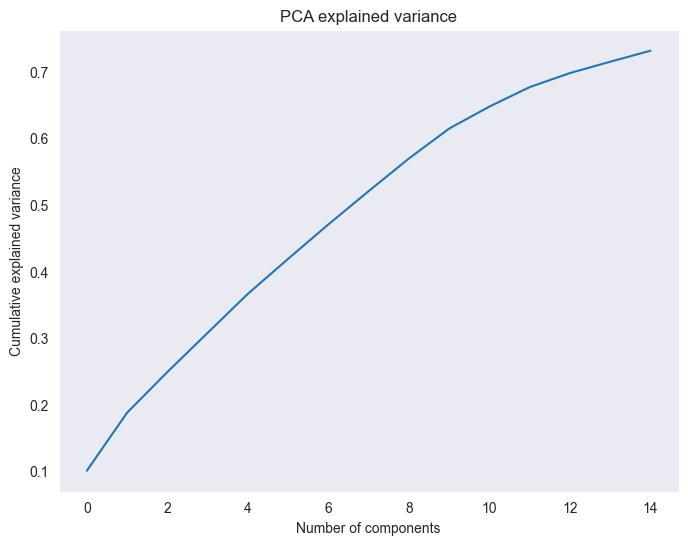

In [17]:
plt.figure(figsize=(8, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.grid()
plt.show()

In [18]:
clusterer = HDBSCAN(
    min_cluster_size=500,
    min_samples=50,
    metric="euclidean"
)

labels = clusterer.fit_predict(X_pca)
df["cluster"] = labels

df["cluster"].value_counts().head()

cluster
 18    134308
 19     78230
-1      51238
 13     20105
 28     16526
Name: count, dtype: int64

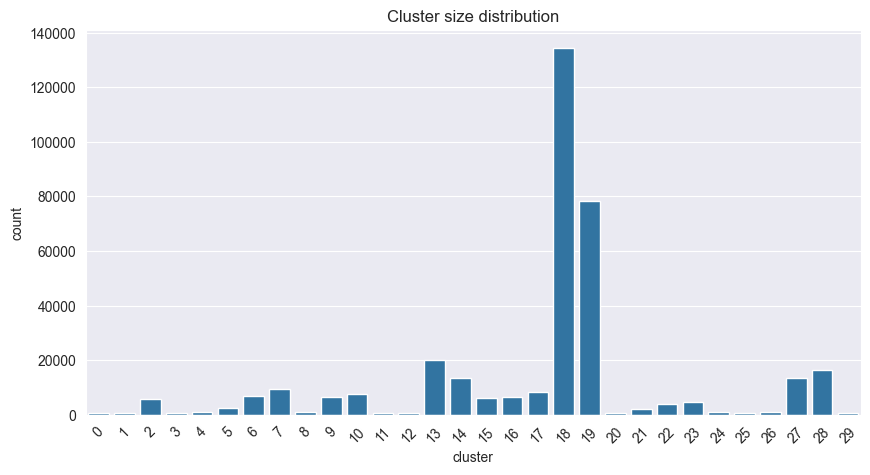

In [19]:
plt.figure(figsize=(10, 5))
sns.countplot(x="cluster", data=df[df.cluster != -1])
plt.title("Cluster size distribution")
plt.xticks(rotation=45)
plt.show()

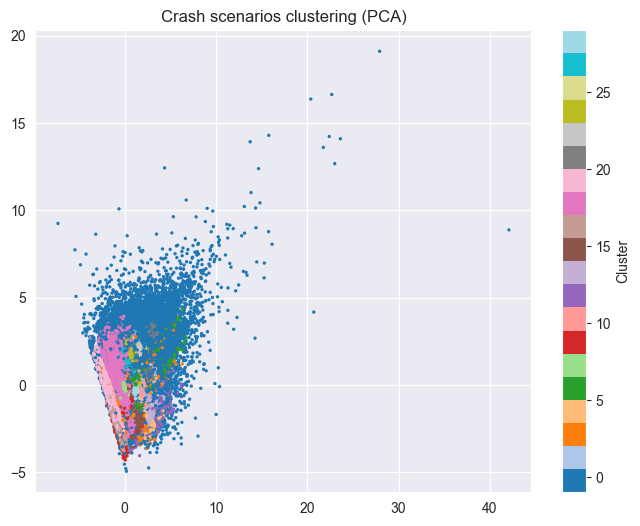

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"],
    cmap="tab20",
    s=2
)
plt.colorbar(label="Cluster")
plt.title("Crash scenarios clustering (PCA)")
plt.show()

In [21]:
cluster_summary = (
    df[df.cluster != -1]
    .groupby("cluster")
    .agg(
        crashes=("cluster", "count"),
        fatalities_mean=("Count_Casualty_Fatality", "mean"),
        severity_mode=("Crash_Severity", lambda x: x.value_counts().idxmax()),
        top_dca=("Crash_DCA_Group_Description", lambda x: x.value_counts().head(3).index.tolist()),
        lighting=("Crash_Lighting_Condition", lambda x: x.value_counts().idxmax()),
        speed_limit=("Crash_Speed_Limit", lambda x: x.value_counts().idxmax())
    )
    .sort_values("crashes", ascending=False)
)

cluster_summary.head()

,crashes,fatalities_mean,severity_mode,top_dca,lighting,speed_limit
cluster,,,,,,
18,134308,0.0,Medical treatment,"[04: Rear-end, 01: Intersection: Adjacent Appr...",Daylight,60 km/h
19,78230,0.0,Property damage only,"[04: Rear-end, 01: Intersection: Adjacent Appr...",Daylight,60 km/h
13,20105,0.0,Hospitalisation,"[01: Intersection: Adjacent Approach, 03: Oppo...",Daylight,60 km/h
28,16526,0.0,Hospitalisation,"[16: Off Carriageway on Straight Hit Object, 1...",Daylight,100 - 110 km/h
27,13507,0.0,Hospitalisation,"[01: Intersection: Adjacent Approach, 04: Rear...",Daylight,60 km/h


In [22]:
CLUSTER_ID = 0

df[df.cluster == CLUSTER_ID].describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Crash_Year,676.0,NaN,NaN,NaN,2011.41568,7.139892,2001.0,2005.0,2011.0,2017.25,2024.0
Crash_Month,676,12,May,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crash_Day_Of_Week,676,7,Saturday,127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crash_Hour,676.0,NaN,NaN,NaN,13.158284,6.880145,0.0,8.0,15.0,19.0,23.0
Crash_Road_Surface_Condition,676,5,Sealed - Dry,590,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crash_Atmospheric_Condition,676,5,Clear,610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crash_Lighting_Condition,676,4,Daylight,276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crash_Roadway_Feature,676,9,No Roadway Feature,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crash_Traffic_Control,676,8,No traffic control,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crash_Speed_Limit,676,5,60 km/h,296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
